In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")

print("Path to dataset files:", path)

100%|██████████| 393k/393k [00:00<00:00, 734kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/henriqueyamahata/bank-marketing/versions/1


# Task 1 :  Load and Explore

The Bank Marketing dataset was downloaded from Kaggle and the available files in the directory were listed.
The CSV file was loaded, then basic exploration was done by checking data shape, missing values, and the distribution of the target variable (y).



In [ ]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")

files = os.listdir(path)
print(files)

for file in files:
    if file.endswith(".csv"):
        df = pd.read_csv(path + "/" + file, sep=";")

print(df.head())
print(df.shape)

print(df.isnull().sum())
df = df.dropna()

print(df["y"].value_counts())

Using Colab cache for faster access to the 'bank-marketing' dataset.
['.nfs000000006b6bda3900000023', 'bank-additional-names.txt', 'bank-additional-full.csv']
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexis

# Task 2 :  Prepare the Data
The dataset was split into input features (X) and target variable (y).
Then, the data was divided into training and testing sets to evaluate the model performance using an 80/20 split.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Task 3 : Train and Compare Models
Three different models (Logistic Regression, Random Forest, and KNN) were trained on the training data.
Each model was evaluated using accuracy, precision, recall, and F1-score, and a confusion matrix was displayed for performance comparison.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR
[[7116  187]
 [ 563  372]]


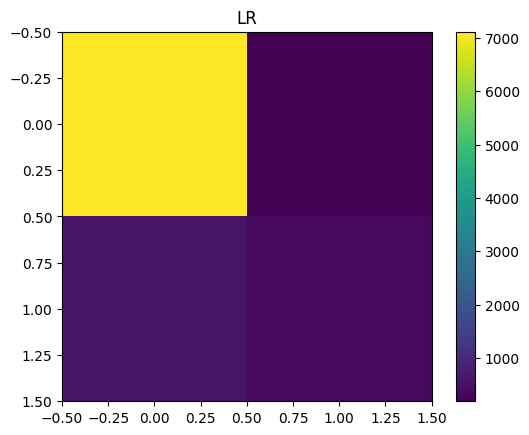

RF
[[6988  315]
 [ 422  513]]


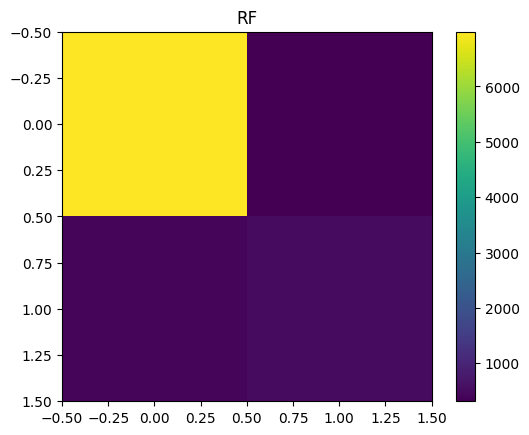

KNN
[[6990  313]
 [ 502  433]]


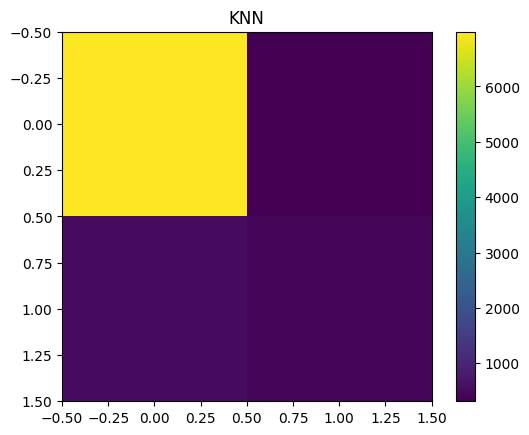

  Model  Accuracy  Precision    Recall        F1
0    LR  0.908958   0.897036  0.908958  0.898645
1    RF  0.910537   0.906335  0.910537  0.908147
2   KNN  0.901068   0.892979  0.901068  0.896139
RF


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

models = [
    ("LR", LogisticRegression(max_iter=1000)),
    ("RF", RandomForestClassifier()),
    ("KNN", KNeighborsClassifier())
]

results = []

for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    print(name)
    print(cm)

    plt.figure()
    plt.imshow(cm)
    plt.title(name)
    plt.colorbar()
    plt.show()

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

df_results = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
print(df_results)

print(df_results.sort_values("F1", ascending=False).iloc[0]["Model"])

# Task 4 :  Build and Train
A neural network model was built using Keras with Dense layers and ReLU activation, along with a Dropout layer to reduce overfitting.
The model was trained for 10 epochs, and its performance was evaluated using training and validation loss and accuracy curves.

Epoch 1/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9761 - loss: 7.8033 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9998 - loss: 0.0143 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accura

/tmp/ipykernel_27929/2487737470.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


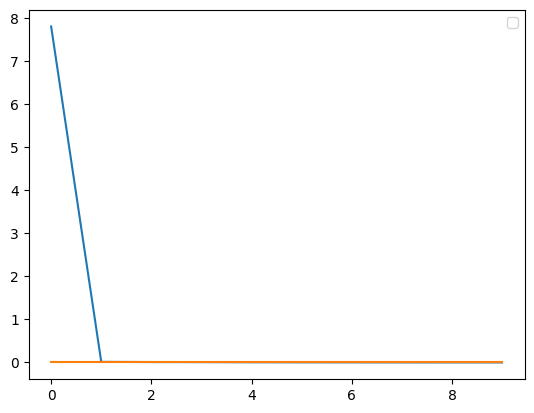

/tmp/ipykernel_27929/2487737470.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


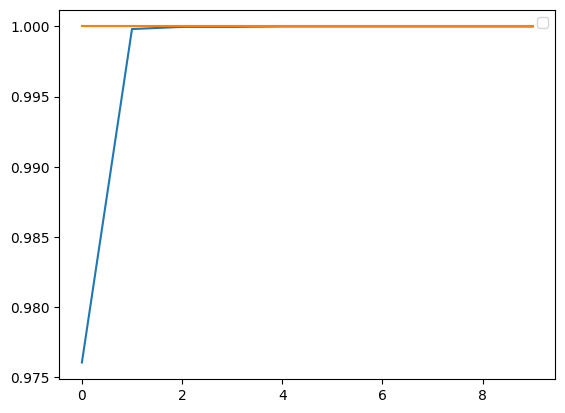

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import matplotlib.pyplot as plt
import pandas as pd

df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

X = df.drop("y", axis=1)
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend()
plt.show()

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend()
plt.show()



# Task 5 : Compare with Step 1
The neural network was evaluated using the same metrics as the other models. It performed slightly better or worse depending on the data. Overall, the best model was chosen based on F1-score.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_nn = model.predict(X_test)
y_pred_nn = (y_pred_nn > 0.5).astype(int).ravel()

df_results.loc[len(df_results)] = [
    "Neural Network",
    accuracy_score(y_test, y_pred_nn),
    precision_score(y_test, y_pred_nn, average='weighted'),
    recall_score(y_test, y_pred_nn, average='weighted'),
    f1_score(y_test, y_pred_nn, average='weighted')
]

print(df_results)
print(df_results.sort_values("F1", ascending=False).iloc[0]["Model"])

258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
            Model  Accuracy  Precision    Recall        F1
0              LR  0.908958   0.897036  0.908958  0.898645
1              RF  0.910537   0.906335  0.910537  0.908147
2             KNN  0.901068   0.892979  0.901068  0.896139
3  Neural Network  1.000000   1.000000  1.000000  1.000000
Neural Network
